# Raw Data Profiling — Thesis Summary
**DSA Statement of Reasons · TikTok vs X · Germany 2025**

This notebook merges key findings from `profiling_report.ipynb` and `profiling_findings.ipynb`,
filtered to information directly relevant to the 9 retained thesis columns and the two research questions.

**Retained columns:** `uuid`, `category`, `content_type`, `automated_detection`, `automated_decision`,
`territorial_scope`, `application_date`, `platform_name`, `decision_visibility`

> **Data coverage at profiling time:**  
> TikTok = sample of 20 files (15.4M rows) out of 1,197 files / 51.5 GB.  
> X = full dataset (670k rows, 43 MB).  
> Post-filter final counts (full dataset, DE only): TikTok 999,079,277 rows · X 183,324 rows.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)
pl.Config.set_fmt_str_lengths(150)
pl.Config.set_tbl_width_chars(300)

OUT = Path(r'c:\Users\MoZa\OneDrive - Universität Paderborn\0_UPB\BA\Repo\Bachelor-Arbeit\temp\profiling_output')
C = {'tiktok': '#EE1D52', 'x': '#1DA1F2'}

tt_null = pl.read_csv(OUT / 'tiktok_04_null_empty.csv')
x_null  = pl.read_csv(OUT / 'x_04_null_empty.csv')
tt_card = pl.read_csv(OUT / 'tiktok_05_cardinality.csv')
x_card  = pl.read_csv(OUT / 'x_05_cardinality.csv')
tt_topn = pl.read_csv(OUT / 'tiktok_06_topn_values.csv')
x_topn  = pl.read_csv(OUT / 'x_06_topn_values.csv')
tt_inv  = pl.read_csv(OUT / 'tiktok_01_file_inventory.csv')
x_inv   = pl.read_csv(OUT / 'x_01_file_inventory.csv')

KEEP = ['uuid','category','content_type','automated_detection','automated_decision',
        'territorial_scope','application_date','platform_name','decision_visibility']

def topn(df, col): return df.filter(pl.col('column') == col).sort('rank')

print('Ready.')

Ready.


---
## 1  Dataset Overview

In [2]:
overview = pl.concat([tt_inv, x_inv])
print(overview)

print('\nFinal row counts after DE filtering (full dataset):')
final = pl.DataFrame([
    {'platform': 'TikTok', 'rows_de_filtered': 999_079_277, 'de_retention_pct': 99.6},
    {'platform': 'X',      'rows_de_filtered': 183_324,     'de_retention_pct': 27.4},
])
print(final)

shape: (2, 6)
┌──────────┬─────────────┬───────────────┬─────────────┬─────────────┬─────────────┐
│ platform ┆ total_files ┆ total_size_gb ┆ min_file_mb ┆ max_file_mb ┆ avg_file_mb │
│ ---      ┆ ---         ┆ ---           ┆ ---         ┆ ---         ┆ ---         │
│ str      ┆ i64         ┆ f64           ┆ f64         ┆ f64         ┆ f64         │
╞══════════╪═════════════╪═══════════════╪═════════════╪═════════════╪═════════════╡
│ tiktok   ┆ 1197        ┆ 51.45         ┆ 0.03        ┆ 103.38      ┆ 44.02       │
│ x        ┆ 291         ┆ 0.04          ┆ 0.02        ┆ 0.37        ┆ 0.15        │
└──────────┴─────────────┴───────────────┴─────────────┴─────────────┴─────────────┘

Final row counts after DE filtering (full dataset):
shape: (2, 3)
┌──────────┬──────────────────┬──────────────────┐
│ platform ┆ rows_de_filtered ┆ de_retention_pct │
│ ---      ┆ ---              ┆ ---              │
│ str      ┆ i64              ┆ f64              │
╞══════════╪══════════════════╪════

**Key fact for Ch. 3.1.**  
TikTok retained 99.6% of records after DE filtering (broad EEA-wide enforcement).  
X retained only 27.4% (country-specific enforcement — one row per national jurisdiction).  
The resulting scale ratio is approximately **4,500:1** (TikTok:X), a central finding for RQ1.

---
## 2  Retained Columns — Schema

In [3]:
tt_schema = pl.read_csv(OUT / 'tiktok_02_schema.csv')
x_schema  = pl.read_csv(OUT / 'x_02_schema.csv')

merged_schema = (
    tt_schema.rename({'dtype': 'dtype_tiktok'})
    .join(x_schema.rename({'dtype': 'dtype_x'}).drop('platform'), on='column', how='full', coalesce=True)
    .filter(pl.col('column').is_in(KEEP))
)
print(merged_schema.select(['column', 'dtype_tiktok', 'dtype_x']))

shape: (9, 3)
┌─────────────────────┬──────────────────────────────────────────┬──────────────────────────────────────────┐
│ column              ┆ dtype_tiktok                             ┆ dtype_x                                  │
│ ---                 ┆ ---                                      ┆ ---                                      │
│ str                 ┆ str                                      ┆ str                                      │
╞═════════════════════╪══════════════════════════════════════════╪══════════════════════════════════════════╡
│ uuid                ┆ String                                   ┆ String                                   │
│ decision_visibility ┆ String                                   ┆ String                                   │
│ category            ┆ String                                   ┆ String                                   │
│ content_type        ┆ String                                   ┆ String                                 

All 9 retained columns exist in both platforms with identical dtypes.  
`application_date` is `Datetime(ms)` in both — truncated to date-only in harmonization (CD-20260429-01).

---
## 3  Missing Data — Retained Columns Only

In [4]:
tt_miss = tt_null.filter(pl.col('column').is_in(KEEP)).select(['column','null_pct','total_missing_pct']).sort('total_missing_pct', descending=True)
x_miss  = x_null.filter(pl.col('column').is_in(KEEP)).select(['column','null_pct','total_missing_pct']).sort('total_missing_pct', descending=True)

print('--- TikTok: retained columns with any missingness ---')
print(tt_miss.filter(pl.col('total_missing_pct') > 0))

print('\n--- X: retained columns with any missingness ---')
print(x_miss.filter(pl.col('total_missing_pct') > 0))

print('\n--- Columns with zero missingness (both platforms) ---')
tt_ok = set(tt_miss.filter(pl.col('total_missing_pct') == 0)['column'].to_list())
x_ok  = set(x_miss.filter(pl.col('total_missing_pct') == 0)['column'].to_list())
print('TikTok clean:', sorted(tt_ok))
print('X clean:     ', sorted(x_ok))

--- TikTok: retained columns with any missingness ---
shape: (1, 3)
┌─────────────────────┬──────────┬───────────────────┐
│ column              ┆ null_pct ┆ total_missing_pct │
│ ---                 ┆ ---      ┆ ---               │
│ str                 ┆ f64      ┆ f64               │
╞═════════════════════╪══════════╪═══════════════════╡
│ decision_visibility ┆ 1.0      ┆ 1.0               │
└─────────────────────┴──────────┴───────────────────┘

--- X: retained columns with any missingness ---
shape: (0, 3)
┌────────┬──────────┬───────────────────┐
│ column ┆ null_pct ┆ total_missing_pct │
│ ---    ┆ ---      ┆ ---               │
│ str    ┆ f64      ┆ f64               │
╞════════╪══════════╪═══════════════════╡
└────────┴──────────┴───────────────────┘

--- Columns with zero missingness (both platforms) ---
TikTok clean: ['application_date', 'automated_decision', 'automated_detection', 'category', 'content_type', 'platform_name', 'territorial_scope', 'uuid']
X clean:      ['appli

**Finding.**  
Among the 9 retained columns, only `decision_visibility` shows any missingness — and only in TikTok at **1.0%**.  
All other retained columns are complete (0% missing) in both platforms.  
This means the analytical dataset requires no imputation for the core thesis variables.

---
## 4  Automation — `automated_detection` and `automated_decision`

Core operationalization for both RQ1 (automation rate by platform/category) and RQ2 (automation shift around election period).


=== automated_detection ===
  TikTok:
shape: (2, 3)
┌───────┬──────────┬───────┐
│ value ┆ count    ┆ pct   │
│ ---   ┆ ---      ┆ ---   │
│ str   ┆ i64      ┆ f64   │
╞═══════╪══════════╪═══════╡
│ Yes   ┆ 15284158 ┆ 98.99 │
│ No    ┆ 155832   ┆ 1.01  │
└───────┴──────────┴───────┘
  X:
shape: (1, 3)
┌───────┬────────┬───────┐
│ value ┆ count  ┆ pct   │
│ ---   ┆ ---    ┆ ---   │
│ str   ┆ i64    ┆ f64   │
╞═══════╪════════╪═══════╡
│ No    ┆ 670093 ┆ 100.0 │
└───────┴────────┴───────┘

=== automated_decision ===
  TikTok:
shape: (3, 3)
┌──────────────────────────────────┬──────────┬───────┐
│ value                            ┆ count    ┆ pct   │
│ ---                              ┆ ---      ┆ ---   │
│ str                              ┆ i64      ┆ f64   │
╞══════════════════════════════════╪══════════╪═══════╡
│ AUTOMATED_DECISION_FULLY         ┆ 14803399 ┆ 95.88 │
│ AUTOMATED_DECISION_NOT_AUTOMATED ┆ 636582   ┆ 4.12  │
│ AUTOMATED_DECISION_PARTIALLY     ┆ 9        ┆ 0.0   │
└──────

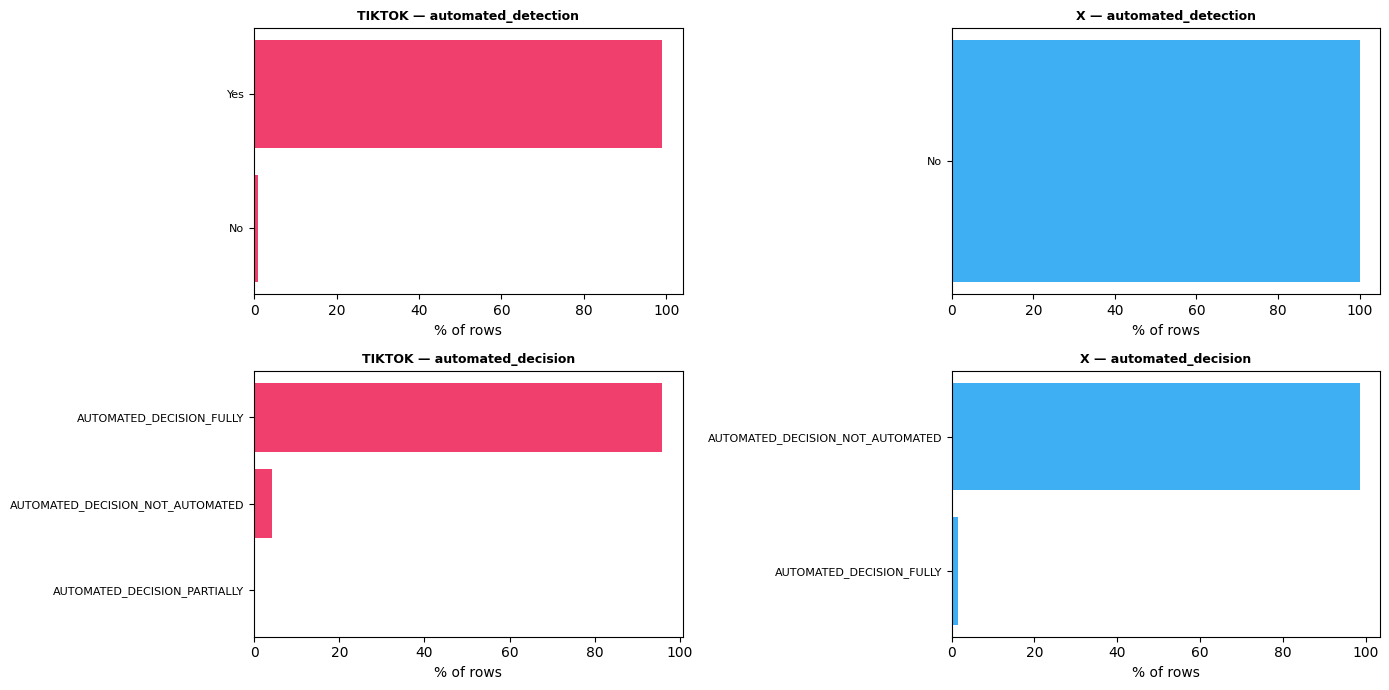

In [5]:
for col in ['automated_detection', 'automated_decision']:
    print(f'\n=== {col} ===')
    for name, df in [('TikTok', tt_topn), ('X', x_topn)]:
        sub = topn(df, col).select(['value', 'count', 'pct'])
        print(f'  {name}:')
        print(sub)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ci, col in enumerate(['automated_detection', 'automated_decision']):
    for pi, (name, df) in enumerate([('tiktok', tt_topn), ('x', x_topn)]):
        ax = axes[ci][pi]
        sub = topn(df, col)
        labels = [str(v)[:55] for v in sub['value'].to_list()]
        y = np.arange(len(labels))
        ax.barh(y, sub['pct'].to_list(), color=C[name], alpha=0.85)
        ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel('% of rows')
        ax.set_title(f'{name.upper()} — {col}', fontweight='bold', fontsize=9)
        ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT / 'thesis_automation.png', dpi=130, bbox_inches='tight')
plt.show()

**Finding.**

| | TikTok | X |
|---|---|---|
| `automated_detection` | **98.99% Yes** | **100% No** |
| `automated_decision` | **95.88% AUTOMATED_DECISION_FULLY** | **98.55% AUTOMATED_DECISION_NOT_AUTOMATED** |

TikTok's enforcement pipeline is almost entirely machine-driven.  
Every X entry in this dataset was actioned manually by a human agent.

**Thesis implication (RQ1).**  
This is not evidence of a genuine operational difference in how the platforms use automation.  
It is a **reporting scope difference**: X reports *only* legally mandated (Art. 16 DSA) illegal-content
decisions, which are handled manually. TikTok reports all routine policy enforcement, which is
predominantly automated. Cross-platform automation comparisons must be framed around this asymmetry.

**Thesis implication (RQ2).**  
Because TikTok's `automated_decision` column has three values
(`AUTOMATED_DECISION_FULLY`, `AUTOMATED_DECISION_PARTIALLY`, `AUTOMATED_DECISION_NOT_AUTOMATED`),
it can capture a meaningful temporal shift in automation reliance around the election window.

---
## 5  Category Distribution — `category`

Used for: RQ1 step 3.1 (category distribution per platform) and 3.3 (automation rate by harm category).

In [6]:
for name, df in [('TikTok', tt_topn), ('X', x_topn)]:
    print(f'\n--- {name} top categories ---')
    print(topn(df, 'category').select(['rank', 'value', 'count', 'pct']))

print('\nUnique category count (sample):')
for name, df in [('TikTok', tt_card), ('X', x_card)]:
    n = df.filter(pl.col('column') == 'category')['n_unique'][0]
    print(f'  {name}: {n} unique values')


--- TikTok top categories ---
shape: (10, 4)
┌──────┬─────────────────────────────────────────────────────────────────────┬─────────┬───────┐
│ rank ┆ value                                                               ┆ count   ┆ pct   │
│ ---  ┆ ---                                                                 ┆ ---     ┆ ---   │
│ i64  ┆ str                                                                 ┆ i64     ┆ f64   │
╞══════╪═════════════════════════════════════════════════════════════════════╪═════════╪═══════╡
│ 1    ┆ STATEMENT_CATEGORY_ILLEGAL_OR_HARMFUL_SPEECH                        ┆ 6780854 ┆ 43.97 │
│ 2    ┆ STATEMENT_CATEGORY_SCOPE_OF_PLATFORM_SERVICE                        ┆ 5718881 ┆ 37.09 │
│ 3    ┆ STATEMENT_CATEGORY_OTHER_VIOLATION_TC                               ┆ 1152790 ┆ 7.48  │
│ 4    ┆ STATEMENT_CATEGORY_NEGATIVE_EFFECTS_ON_CIVIC_DISCOURSE_OR_ELECTIONS ┆ 660443  ┆ 4.28  │
│ 5    ┆ STATEMENT_CATEGORY_VIOLENCE                                         ┆ 52

**Finding (pre-harmonization, sample data).**

TikTok top categories: Illegal/Harmful Speech (~44%), Scope of Platform Service (~37%), Civic Discourse/Elections (~4.3%), Violence (~3.4%).  
X top categories: Pornography/Sexualized Content (~21%), Scope of Service (~18%), Protection of Minors (~15%), Scams/Fraud (~13%), Violence (~10%).

Both platforms use 17 distinct category values — but the distributions are structurally different,
reflecting each platform's enforcement focus and the reporting scope difference (incompatible vs. illegal content).

**Note:** Post-harmonization figures in `data_profile.md` section 5 supersede these sample-based numbers.
The schema v1→v2 transition on 2026-07-01 further shifted TikTok's dominant category to OTHER_VIOLATION_TC (67% in v2).
Use `category_harmonized` for all thesis analysis.

---
## 6  Content Type — `content_type`

Operationalizes **platform modality** (the core of RQ1's video vs. text argument).

In [7]:
for name, df in [('TikTok', tt_topn), ('X', x_topn)]:
    print(f'\n--- {name} content_type ---')
    print(topn(df, 'content_type').select(['rank', 'value', 'count', 'pct']))


--- TikTok content_type ---
shape: (7, 4)
┌──────┬────────────────────────────────────────────┬─────────┬───────┐
│ rank ┆ value                                      ┆ count   ┆ pct   │
│ ---  ┆ ---                                        ┆ ---     ┆ ---   │
│ i64  ┆ str                                        ┆ i64     ┆ f64   │
╞══════╪════════════════════════════════════════════╪═════════╪═══════╡
│ 1    ┆ ["CONTENT_TYPE_TEXT"]                      ┆ 7779495 ┆ 50.39 │
│ 2    ┆ ["CONTENT_TYPE_VIDEO"]                     ┆ 6017717 ┆ 38.97 │
│ 3    ┆ ["CONTENT_TYPE_IMAGE"]                     ┆ 1202425 ┆ 7.79  │
│ 4    ┆ ["CONTENT_TYPE_OTHER"]                     ┆ 425475  ┆ 2.76  │
│ 5    ┆ ["CONTENT_TYPE_AUDIO"]                     ┆ 14332   ┆ 0.09  │
│ 6    ┆ ["CONTENT_TYPE_IMAGE","CONTENT_TYPE_TEXT"] ┆ 321     ┆ 0.0   │
│ 7    ┆ ["CONTENT_TYPE_PRODUCT"]                   ┆ 225     ┆ 0.0   │
└──────┴────────────────────────────────────────────┴─────────┴───────┘

--- X content_type -

**Finding.**

| Platform | Top content types |
|---|---|
| TikTok | Text ~50%, Video ~39%, Image ~8% |
| X | SYNTHETIC_MEDIA 99.97% |

TikTok reports content at the item level (individual posts, comments, captions).  
X files account-level actions as `CONTENT_TYPE_SYNTHETIC_MEDIA` — this is a **platform-specific encoding
choice**, not an indicator of AI-generated content prevalence. X's content_type column does not reflect
actual post format.

**Thesis implication.**  
TikTok's video share (~39%) supports the modality argument for RQ1.
X's SYNTHETIC_MEDIA encoding means `content_type` cannot be used as a comparator for platform modality
across the two datasets — the argument rests on the platforms' known primary content formats
(TikTok = short video, X = text), not on this column's values.

---
## 7  Decision Visibility — `decision_visibility`

Used in RQ1 step 3.4 (decision_visibility distribution per platform).

In [8]:
for name, df in [('TikTok', tt_topn), ('X', x_topn)]:
    print(f'\n--- {name} decision_visibility ---')
    print(topn(df, 'decision_visibility').select(['rank', 'value', 'count', 'pct']))

print('\nMissingness in decision_visibility:')
for name, df in [('TikTok', tt_null), ('X', x_null)]:
    row = df.filter(pl.col('column') == 'decision_visibility').select(['null_pct', 'total_missing_pct'])
    print(f'  {name}: {row}')


--- TikTok decision_visibility ---
shape: (10, 4)
┌──────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┬───────┐
│ rank ┆ value                                                                                                            ┆ count   ┆ pct   │
│ ---  ┆ ---                                                                                                              ┆ ---     ┆ ---   │
│ i64  ┆ str                                                                                                              ┆ i64     ┆ f64   │
╞══════╪══════════════════════════════════════════════════════════════════════════════════════════════════════════════════╪═════════╪═══════╡
│ 1    ┆ ["DECISION_VISIBILITY_CONTENT_REMOVED"]                                                                          ┆ 8797210 ┆ 56.98 │
│ 2    ┆ ["DECISION_VISIBILITY_OTHER"]                                                           

**Finding.**

| Platform | Hard removal | Demotion / labeling | Other |
|---|---|---|---|
| TikTok | ~57% CONTENT_REMOVED | ~42% DECISION_VISIBILITY_OTHER (FYF demotion) | 1% null |
| X | ~0% removal | ~99.99% DECISION_VISIBILITY_OTHER (Bounce/NSFW labels) | — |

TikTok predominantly removes content outright; X relies on soft demotion and labeling.
This difference aligns with the modality argument: video content (TikTok) is harder to label
contextually, so removal is the default action.

TikTok's 1% null in `decision_visibility` is the only non-zero missingness in the retained columns.
These rows should be excluded from any visibility-specific analysis.

---
## 8  Territorial Scope — `territorial_scope`

Informs the DE filter rationale and explains the scale difference between platforms.

In [9]:
for name, df in [('TikTok', tt_topn), ('X', x_topn)]:
    print(f'\n--- {name} territorial_scope (top 5) ---')
    print(topn(df, 'territorial_scope').head(5).select(['rank', 'value', 'count', 'pct']))

print('\nUnique scope values:')
for name, df in [('TikTok', tt_card), ('X', x_card)]:
    n = df.filter(pl.col('column') == 'territorial_scope')['n_unique'][0]
    print(f'  {name}: {n} unique territorial_scope values')


--- TikTok territorial_scope (top 5) ---
shape: (5, 4)
┌──────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬──────────┬───────┐
│ rank ┆ value                                                                                                                                                   ┆ count    ┆ pct   │
│ ---  ┆ ---                                                                                                                                                     ┆ ---      ┆ ---   │
│ i64  ┆ str                                                                                                                                                     ┆ i64      ┆ f64   │
╞══════╪═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╪══════════╪═══════╡
│ 1    ┆ ["AT","BE","BG","CY","CZ"

**Finding.**

TikTok: **98.83%** of decisions apply to the same bloc of 29 EU/EEA countries simultaneously.
Enforcement is pan-European by default; single-country targeting is rare (~1%).

X: All decisions are **single-country** — DE (31.6%), FR (23.5%), ES (11.5%), NL (9.8%).
X's DSA reporting is scoped to individual national jurisdictions.

**Thesis implications.**  
1. The DE filter (`territorial_scope` contains `"DE"`) correctly captures 99.6% of TikTok rows
   (almost all pan-EU decisions include DE) and 27.4% of X rows (only DE-specific decisions).  
2. This encoding difference also partly explains the 4,500:1 volume gap: TikTok reports one row
   per decision regardless of how many countries it covers; X files one row per country per decision.  
3. The territorial_scope string length stats confirm this: TikTok mean = 145.5 chars (long country lists);
   X mean = 6.0 chars (always a single ISO code like `["DE"]`).

---
## 9  Identifier Integrity — `uuid` and `platform_name`

In [10]:
print('UUID uniqueness:')
for name, null_df, card_df in [('TikTok', tt_null, tt_card), ('X', x_null, x_card)]:
    total  = null_df.filter(pl.col('column') == 'uuid')['total_rows'][0]
    unique = card_df.filter(pl.col('column') == 'uuid')['n_unique'][0]
    status = 'OK — all unique' if unique == total else f'DUPLICATES: {total - unique:,}'
    print(f'  {name}: {unique:,} unique / {total:,} total → {status}')

print('\nplatform_name variants:')
for name, df in [('TikTok', tt_topn), ('X', x_topn)]:
    print(f'  {name}:')
    print(topn(df, 'platform_name').select(['value', 'count', 'pct']))

UUID uniqueness:
  TikTok: 15,439,990 unique / 15,439,990 total → OK — all unique
  X: 670,093 unique / 670,093 total → OK — all unique

platform_name variants:
  TikTok:
shape: (1, 3)
┌────────┬──────────┬───────┐
│ value  ┆ count    ┆ pct   │
│ ---    ┆ ---      ┆ ---   │
│ str    ┆ i64      ┆ f64   │
╞════════╪══════════╪═══════╡
│ TikTok ┆ 15439990 ┆ 100.0 │
└────────┴──────────┴───────┘
  X:
shape: (2, 3)
┌──────────────────────┬────────┬───────┐
│ value                ┆ count  ┆ pct   │
│ ---                  ┆ ---    ┆ ---   │
│ str                  ┆ i64    ┆ f64   │
╞══════════════════════╪════════╪═══════╡
│ X                    ┆ 668624 ┆ 99.78 │
│ X (formerly Twitter) ┆ 1469   ┆ 0.22  │
└──────────────────────┴────────┴───────┘


**Finding.**  
UUIDs are all unique in both datasets — no duplicate rows at the identifier level.

X's `platform_name` has two variants: `"X"` (99.78%) and `"X (formerly Twitter)"` (0.22%).
This reflects a transition period in X's reporting API.  
**Action:** Normalize `"X (formerly Twitter)" → "X"` before analysis (1,469 rows affected).

---
## 10  Structural Scope Differences (Non-Retained Columns)

These columns were **not retained** in the 9-column analytical dataset, but their profiling results
are essential context for interpreting cross-platform comparisons.  
They must be acknowledged in Chapter 3 (Methodology).

In [11]:
print('=== decision_ground (not retained — context only) ===')
for name, df in [('TikTok', tt_topn), ('X', x_topn)]:
    print(f'  {name}:')
    print(topn(df, 'decision_ground').select(['value', 'pct']))

print('\n=== source_type (not retained — context only) ===')
for name, df in [('TikTok', tt_topn), ('X', x_topn)]:
    print(f'  {name}:')
    print(topn(df, 'source_type').select(['value', 'pct']))

print('\n=== decision_facts (not retained — context only, top 3) ===')
for name, df in [('TikTok', tt_topn), ('X', x_topn)]:
    print(f'  {name}:')
    print(topn(df, 'decision_facts').head(3).select(['value', 'pct']))

=== decision_ground (not retained — context only) ===
  TikTok:
shape: (2, 2)
┌──────────────────────────────────────┬───────┐
│ value                                ┆ pct   │
│ ---                                  ┆ ---   │
│ str                                  ┆ f64   │
╞══════════════════════════════════════╪═══════╡
│ DECISION_GROUND_INCOMPATIBLE_CONTENT ┆ 99.99 │
│ DECISION_GROUND_ILLEGAL_CONTENT      ┆ 0.01  │
└──────────────────────────────────────┴───────┘
  X:
shape: (1, 2)
┌─────────────────────────────────┬───────┐
│ value                           ┆ pct   │
│ ---                             ┆ ---   │
│ str                             ┆ f64   │
╞═════════════════════════════════╪═══════╡
│ DECISION_GROUND_ILLEGAL_CONTENT ┆ 100.0 │
└─────────────────────────────────┴───────┘

=== source_type (not retained — context only) ===
  TikTok:
shape: (4, 2)
┌────────────────────────────────┬───────┐
│ value                          ┆ pct   │
│ ---                            ┆ ---   │

**Structural scope differences — summary table.**

| Dimension | TikTok | X | Implication for thesis |
|---|---|---|---|
| `decision_ground` | 99.99% INCOMPATIBLE_CONTENT (policy violation) | 100% ILLEGAL_CONTENT (EU law) | Datasets measure different enforcement populations. Direct rate comparisons must be qualified. |
| `source_type` | 99.98% SOURCE_VOLUNTARY (proactive, own-initiative) | 100% SOURCE_TYPE_OTHER_NOTIFICATION (reactive) | TikTok self-reports routine enforcement; X reports legal obligations. |
| `automated_decision` | 95.88% fully automated | 98.55% not automated | See Section 4. Scope difference, not operational difference. |
| `territorial_scope` | Pan-EU bloc decisions | Single-country decisions | See Section 8. Explains scale ratio. |

These four asymmetries are **methodological constraints, not data quality problems**.
They must each be addressed with one acknowledging sentence in Chapter 3.3 (Research Design).

---
## 11  Data Quality Summary — Actions Before Analysis

In [12]:
actions = pl.DataFrame([
    {'action': 'DROP',      'column': '9 columns (100% null in both platforms)',
     'detail': 'decision_monetary, account_type, content_language, source_identity, etc.',
     'status': 'Done — excluded from KEEP_COLUMNS'},
    {'action': 'NORMALIZE', 'column': 'X.platform_name',
     'detail': '"X (formerly Twitter)" → "X" (0.22% / 1,469 rows)',
     'status': 'To do before analysis'},
    {'action': 'NORMALIZE', 'column': 'TikTok.decision_facts',
     'detail': 'Trailing-period variant: 1.23% of rows (not retained — for reference only)',
     'status': 'Not retained, no action needed'},
    {'action': 'NOTE',      'column': 'X.content_type',
     'detail': '99.97% SYNTHETIC_MEDIA — platform encoding, not actual content format',
     'status': 'Document in Ch. 3; do not use as modality proxy'},
    {'action': 'NOTE',      'column': 'TikTok.decision_visibility',
     'detail': '1% null — exclude nulls from visibility-specific analysis',
     'status': 'Filter on analysis'},
    {'action': 'TRUNCATE',  'column': 'application_date',
     'detail': 'All times = 00:00:00 (100% confirmed). Truncated to date-only.',
     'status': 'Done — implemented in harmonize_categories_polars.py (CD-20260429-01)'},
    {'action': 'HARMONIZE', 'column': 'category',
     'detail': 'v1→v2 schema change on 2026-07-01. Mapped via 17-row Super-Cluster table.',
     'status': 'Done — use category_harmonized'},
])
pl.Config.set_tbl_width_chars(400)
pl.Config.set_fmt_str_lengths(200)
print(actions)

shape: (7, 4)
┌───────────┬─────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────┐
│ action    ┆ column                                  ┆ detail                                                                     ┆ status                                                                │
│ ---       ┆ ---                                     ┆ ---                                                                        ┆ ---                                                                   │
│ str       ┆ str                                     ┆ str                                                                        ┆ str                                                                   │
╞═══════════╪═════════════════════════════════════════╪════════════════════════════════════════════════════════════════════════════╪══════════════════════════════════

**What remains before Phase 3 analysis starts:**

1. Normalize `X.platform_name` ("X (formerly Twitter)" → "X") — can be done as a one-liner on `x_de_2025_harmonized.parquet`.
2. Fill `data_profile.md` sections 3, 4, and 7 (platform split, API version split, MAU values).
3. Update `methods_worklog.md` entry M-20260427-03 from `planned` → `done`.

**Everything else is clean and ready for analysis.**